In [5]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch



In [6]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

[rank: 0] Seed set to 0


Last run with scvi-tools version: 1.4.2


In [7]:
adata = sc.read_h5ad("../data/covid/results/alldata.h5ad")

/shared/projects/tp_2616_fnom_183960/conda/envs/PP_py_scvi/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [8]:
adata

AnnData object with n_obs × n_vars = 7134 × 18854
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'type', 'percent_mito', 'percent_ribo', 'percent_hb', 'percent_plat', 'pct_chrY', 'S.Score', 'G2M.Score', 'Phase', 'pANN_0.25_0.09_297', 'DF.classifications_0.25_0.09_297'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'vf_vst_counts.covid_1_mean', 'vf_vst_counts.covid_1_variance', 'vf_vst_counts.covid_1_variance.expected', 'vf_vst_counts.covid_1_variance.standardized', 'vf_vst_counts.covid_1_variable', 'vf_vst_counts.covid_1_rank', 'vf_vst_counts.covid_15_mean', 'vf_vst_counts.covid_15_variance', 'vf_vst_counts.covid_15_variance.expected', 'vf_vst_counts.covid_15_variance.standardized', 'vf_vst_counts.covid_15_variable', 'vf_vst_counts.covid_15_rank', 'vf_vst_counts.covid_16_mean', 'vf_vst_counts.covid_16_variance', 'vf_vst_counts.covid_16_variance.expec

In [9]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14617022 stored elements and shape (7134, 18854)>

In [10]:
print(adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14617022 stored elements and shape (7134, 18854)>
  Coords	Values
  (0, 32)	1.0
  (0, 53)	1.0
  (0, 72)	1.0
  (0, 96)	1.0
  (0, 180)	2.0
  (0, 199)	1.0
  (0, 219)	1.0
  (0, 260)	1.0
  (0, 292)	2.0
  (0, 327)	1.0
  (0, 338)	10.0
  (0, 339)	1.0
  (0, 403)	1.0
  (0, 405)	1.0
  (0, 410)	1.0
  (0, 417)	1.0
  (0, 446)	1.0
  (0, 463)	1.0
  (0, 481)	1.0
  (0, 528)	3.0
  (0, 534)	1.0
  (0, 559)	1.0
  (0, 576)	1.0
  (0, 588)	1.0
  (0, 590)	2.0
  :	:
  (7133, 18516)	1.0
  (7133, 18541)	1.0
  (7133, 18546)	4.0
  (7133, 18555)	3.0
  (7133, 18576)	3.0
  (7133, 18597)	1.0
  (7133, 18600)	1.0
  (7133, 18674)	2.0
  (7133, 18686)	2.0
  (7133, 18687)	1.0
  (7133, 18695)	1.0
  (7133, 18708)	1.0
  (7133, 18716)	1.0
  (7133, 18719)	2.0
  (7133, 18723)	2.0
  (7133, 18726)	1.0
  (7133, 18745)	1.0
  (7133, 18759)	1.0
  (7133, 18780)	1.0
  (7133, 18784)	1.0
  (7133, 18789)	1.0
  (7133, 18791)	3.0
  (7133, 18815)	6.0
  (7133, 18841)	1.0
  (7133, 18843

In [11]:
sc.pp.filter_genes(adata, min_counts=3)
adata.layers["counts"] = adata.X.copy()  # preserve counts
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # freeze the state in `.raw`

In [12]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="orig.ident",
)

In [13]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,type,percent_mito,percent_ribo,percent_hb,percent_plat,pct_chrY,S.Score,G2M.Score,Phase,pANN_0.25_0.09_297,DF.classifications_0.25_0.09_297
covid_1_TAGAGTCGTCCTCCAT-1,covid_1,1613.0,779,Covid,11.531308,5.951643,0.000000,0.495970,0.000000,-0.026241,-0.061126,G1,0.278027,Singlet
covid_1_CCCTGATAGCGAACTG-1,covid_1,9482.0,2036,Covid,8.025733,43.840962,0.031639,0.021093,0.094917,-0.012075,-0.018898,G1,0.122197,Singlet
covid_1_ATTTACCCAAGCCTGC-1,covid_1,12466.0,3290,Covid,5.502968,18.297770,0.008022,0.040109,0.072196,-0.057578,-0.055722,G1,0.290359,Singlet
covid_1_GTTGTCCTCTAGAACC-1,covid_1,5541.0,1606,Covid,12.759430,30.030680,0.054142,0.162426,0.126331,0.009861,0.013328,G2M,0.110987,Singlet
covid_1_AATAGAGGTGTGAGCA-1,covid_1,4736.0,1285,Covid,12.816723,35.663007,0.105574,0.232264,0.126689,-0.025623,-0.022202,G1,0.192825,Singlet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ctrl_19_TTCTTGAGTATCAGGG-19,ctrl_19,32271.0,5252,Ctrl,7.375043,18.979889,0.000000,0.052679,0.055778,-0.014304,0.001104,G2M,0.239910,Singlet
ctrl_19_GTAGCTAGTAATGCTC-19,ctrl_19,4083.0,1479,Ctrl,10.311046,17.658584,1.322557,0.000000,0.024492,0.030917,-0.013644,S,0.104260,Singlet
ctrl_19_GCCAACGGTAAGTTAG-19,ctrl_19,5137.0,1861,Ctrl,9.188242,18.551684,0.097333,0.058400,0.097333,-0.010992,-0.035542,G1,0.105381,Singlet
ctrl_19_TCGGGACAGTCGTCTA-19,ctrl_19,9398.0,2609,Ctrl,5.682060,28.516706,0.000000,0.010641,0.148968,0.137896,-0.003011,S,0.181614,Singlet


In [14]:
adata.obs["orig_ident"] = adata.obs["orig.ident"]

scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    categorical_covariate_keys=["orig_ident"],
    continuous_covariate_keys=["percent_mito", "percent_ribo"],
)

In [15]:
model = scvi.model.SCVI(adata)
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [16]:
model.train()
model_dir = "../data/covid/results/scvi_model"
model.save(model_dir, overwrite=True)

/shared/projects/tp_2616_fnom_183960/conda/envs/PP_py_scvi/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared/projects/tp_2616_fnom_183960/conda/envs/PP_p ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/shared/projects/tp_2616_fnom_183960/conda/envs/PP_py_scvi/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python 

Epoch 400/400: 100%|██████████| 400/400 [14:17<00:00,  2.36s/it, v_num=1, train_loss=764]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [14:17<00:00,  2.14s/it, v_num=1, train_loss=764]


In [17]:
model_dir = "../data/covid/results/scvi_model"
model = scvi.model.SCVI.load(model_dir, adata=adata)

INFO     File ../data/covid/results/scvi_model/model.pt already downloaded                                         


/shared/projects/tp_2616_fnom_183960/conda/envs/PP_py_scvi/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared/projects/tp_2616_fnom_183960/conda/envs/PP_p ...


In [18]:
SCVI_LATENT_KEY = "X_scVI"
latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(7134, 10)

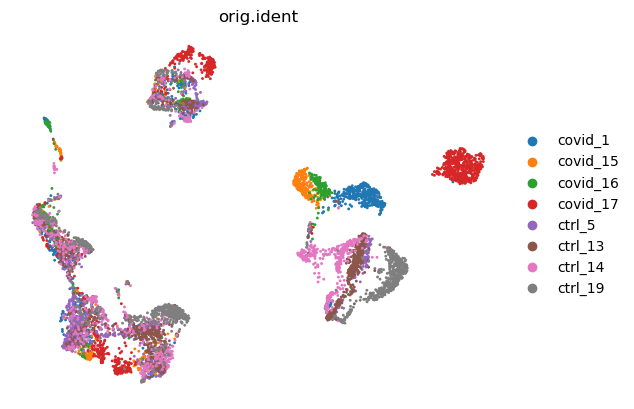

In [19]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

sc.pl.umap(
    adata,
    color=["orig.ident"],
    frameon=False,
)

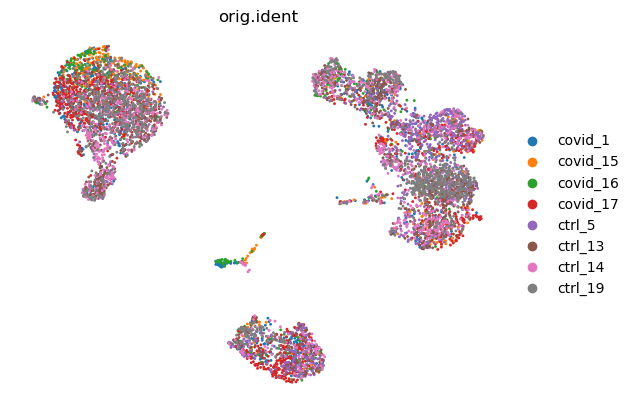

In [20]:

sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.3)


sc.pl.umap(
    adata,
    color=["orig.ident"],
    frameon=False,
)


In [21]:
⚠️ Question: What are the changes you notice between the two UMAPs?

Object `UMAPs` not found.


In [22]:
from scib_metrics.benchmark import Benchmarker


In [23]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,type,percent_mito,percent_ribo,percent_hb,percent_plat,pct_chrY,S.Score,G2M.Score,Phase,pANN_0.25_0.09_297,DF.classifications_0.25_0.09_297,orig_ident,_scvi_batch,_scvi_labels
covid_1_TAGAGTCGTCCTCCAT-1,covid_1,1613.0,779,Covid,11.531308,5.951643,0.000000,0.495970,0.000000,-0.026241,-0.061126,G1,0.278027,Singlet,covid_1,0,0
covid_1_CCCTGATAGCGAACTG-1,covid_1,9482.0,2036,Covid,8.025733,43.840962,0.031639,0.021093,0.094917,-0.012075,-0.018898,G1,0.122197,Singlet,covid_1,0,0
covid_1_ATTTACCCAAGCCTGC-1,covid_1,12466.0,3290,Covid,5.502968,18.297770,0.008022,0.040109,0.072196,-0.057578,-0.055722,G1,0.290359,Singlet,covid_1,0,0
covid_1_GTTGTCCTCTAGAACC-1,covid_1,5541.0,1606,Covid,12.759430,30.030680,0.054142,0.162426,0.126331,0.009861,0.013328,G2M,0.110987,Singlet,covid_1,0,0
covid_1_AATAGAGGTGTGAGCA-1,covid_1,4736.0,1285,Covid,12.816723,35.663007,0.105574,0.232264,0.126689,-0.025623,-0.022202,G1,0.192825,Singlet,covid_1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ctrl_19_TTCTTGAGTATCAGGG-19,ctrl_19,32271.0,5252,Ctrl,7.375043,18.979889,0.000000,0.052679,0.055778,-0.014304,0.001104,G2M,0.239910,Singlet,ctrl_19,0,0
ctrl_19_GTAGCTAGTAATGCTC-19,ctrl_19,4083.0,1479,Ctrl,10.311046,17.658584,1.322557,0.000000,0.024492,0.030917,-0.013644,S,0.104260,Singlet,ctrl_19,0,0
ctrl_19_GCCAACGGTAAGTTAG-19,ctrl_19,5137.0,1861,Ctrl,9.188242,18.551684,0.097333,0.058400,0.097333,-0.010992,-0.035542,G1,0.105381,Singlet,ctrl_19,0,0
ctrl_19_TCGGGACAGTCGTCTA-19,ctrl_19,9398.0,2609,Ctrl,5.682060,28.516706,0.000000,0.010641,0.148968,0.137896,-0.003011,S,0.181614,Singlet,ctrl_19,0,0


In [24]:
bm = Benchmarker(
    adata,
    batch_key="orig.ident",
    label_key="type",
    embedding_obsm_keys=["X_pca","X_integrated_cca","X_harmony","X_integrated.mnn", SCVI_LATENT_KEY],
    n_jobs=-1,
)

In [25]:
bm.benchmark()


/shared/projects/tp_2616_fnom_183960/conda/envs/PP_py_scvi/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Metrics:  70%|███████   | 7/10 [00:21<00:10,  3.41s/it, Batch correction: graph_connectivity]/shared/projects/tp_2616_fnom_183960/conda/envs/PP_py_scvi/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|██        | 1/5 [00:25<01:43, 25.81s/it]atch correction: pcr_comparison]
                                                                                         
Metrics:  70%|██

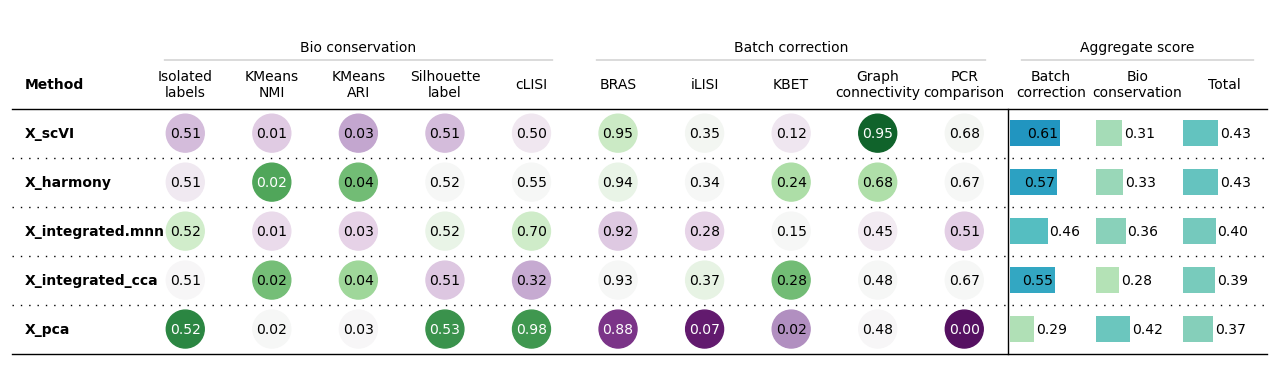

In [26]:
bm.plot_results_table(min_max_scale=False)


In [27]:
df = bm.get_results(min_max_scale=False)
print(df)

                   Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                                
X_pca                      0.52443          0.015878          0.034489   
X_integrated_cca           0.51348          0.020832          0.040594   
X_harmony                 0.512254          0.021822            0.0423   
X_integrated.mnn          0.516919          0.014361          0.031528   
X_scVI                    0.509024           0.01363          0.028719   
Metric Type       Bio conservation  Bio conservation  Bio conservation   

                  Silhouette label             cLISI              BRAS  \
Embedding                                                                
X_pca                     0.531524          0.975305          0.882497   
X_integrated_cca          0.513929          0.320353          0.930831   
X_harmony                 0.518556          0.553427          0.936598   
X_integrated.mnn          0.520191   

In [28]:
import pandas as pd

X_scVI = adata.obsm["X_scVI"]

df = pd.DataFrame(
    X_scVI,
    index=adata.obs_names,
    columns=[f"scVI_{i+1}" for i in range(X_scVI.shape[1])]
)

df.to_csv("../data/covid/results/scvi_model/embeddings_scVI.csv")